# LOAD THE MONTHLY DEFAULT RATE DATASET

In [83]:
import pandas as pd
import numpy as np

In [84]:
monthly_default_rate=pd.read_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\monthly_default_rate.csv")

In [85]:
monthly_default_rate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   issue_month     139 non-null    object 
 1   total_loans     139 non-null    int64  
 2   total_defaults  139 non-null    int64  
 3   default_rate    139 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 4.5+ KB


In [86]:
monthly_default_rate["issue_month"]=pd.to_datetime(monthly_default_rate["issue_month"],errors="coerce")

In [87]:
monthly_default_rate=monthly_default_rate.set_index("issue_month")

In [88]:
monthly_default_rate.head()

,total_loans,total_defaults,default_rate
issue_month,,,
2007-06-01,24,3,0.125000
2007-07-01,63,7,0.111111
2007-08-01,74,20,0.270270
2007-09-01,53,13,0.245283
2007-10-01,105,34,0.323810


# Visual Trend Analysis

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

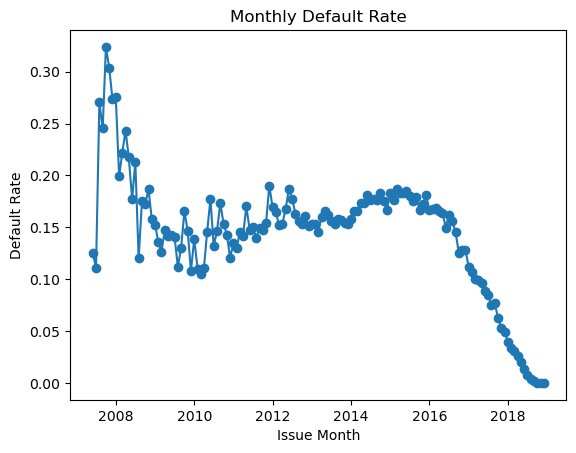

In [90]:
plt.plot(monthly_default_rate.index,monthly_default_rate['default_rate'], linestyle='-', marker='o')
plt.xlabel("Issue Month")
plt.ylabel("Default Rate")
plt.title("Monthly Default Rate")
plt.savefig( r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\01_default_rate_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [91]:
# calculate 3 month rolling rate
monthly_default_rate['default_rate_3m']=monthly_default_rate['total_defaults'].rolling(3).sum()/monthly_default_rate['total_loans'].rolling(3).sum()
monthly_default_rate.head(10)

,total_loans,total_defaults,default_rate,default_rate_3m
issue_month,,,,
2007-06-01,24,3,0.125000,NaN
2007-07-01,63,7,0.111111,NaN
2007-08-01,74,20,0.270270,0.186335
2007-09-01,53,13,0.245283,0.210526
2007-10-01,105,34,0.323810,0.288793
2007-11-01,112,34,0.303571,0.300000
2007-12-01,172,47,0.273256,0.295630
2008-01-01,305,84,0.275410,0.280136
2008-02-01,306,61,0.199346,0.245211


In [92]:
#calculate 6m rolling mean
monthly_default_rate['default_rate_6m']=monthly_default_rate['total_defaults'].rolling(6).sum()/monthly_default_rate['total_loans'].rolling(6).sum()

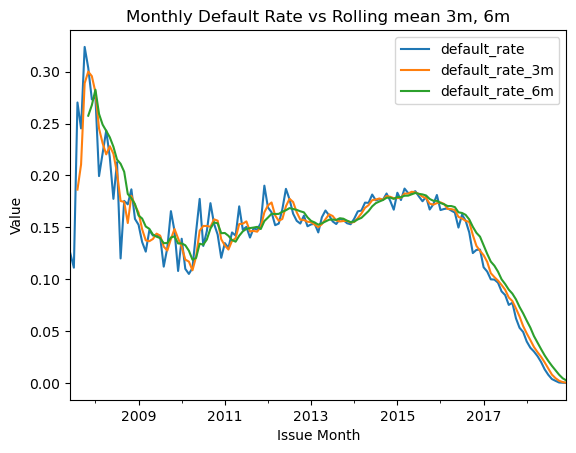

In [93]:
monthly_default_rate[['default_rate','default_rate_3m','default_rate_6m']].plot()
plt.xlabel("Issue Month")
plt.ylabel("Value")
plt.title("Monthly Default Rate vs Rolling mean 3m, 6m")
plt.show()

**OBSERVATIONS FROM THE ABOVE PERFORMED ANALYSIS**
1) Early years highly volatile due to small sample size

2) 2008–2009 likely influenced by GFC

3) 2012–2016 relatively stable credit regime

4) Post-2016 sharp decline likely due to right-censoring bias

In [94]:
# remove the data from 2017-01-01 to 2018-12-01
import datetime
from datetime import date
cut_off_date=date(2017, 1, 1)
monthly_default_rate_cleaned=monthly_default_rate[(monthly_default_rate.index.date<cut_off_date)]
monthly_default_rate_cleaned.tail()

,total_loans,total_defaults,default_rate,default_rate_3m,default_rate_6m
issue_month,,,,,
2016-08-01,36280,5672,0.156340,0.156200,0.161982
2016-09-01,28144,4083,0.145075,0.155196,0.157594
2016-10-01,32772,4102,0.125168,0.142568,0.150491
2016-11-01,34591,4435,0.128213,0.132137,0.144680
2016-12-01,36183,4650,0.128513,0.127354,0.140971


In [95]:
# calculate 3 month rolling rate
monthly_default_rate_cleaned['default_rate_3m']=monthly_default_rate_cleaned['total_defaults'].rolling(3).sum()/monthly_default_rate_cleaned['total_loans'].rolling(3).sum()
monthly_default_rate_cleaned.head(10)

C:\Users\owner's\AppData\Local\Temp\ipykernel_21152\2231993318.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_default_rate_cleaned['default_rate_3m']=monthly_default_rate_cleaned['total_defaults'].rolling(3).sum()/monthly_default_rate_cleaned['total_loans'].rolling(3).sum()


,total_loans,total_defaults,default_rate,default_rate_3m,default_rate_6m
issue_month,,,,,
2007-06-01,24,3,0.125000,NaN,NaN
2007-07-01,63,7,0.111111,NaN,NaN
2007-08-01,74,20,0.270270,0.186335,NaN
2007-09-01,53,13,0.245283,0.210526,NaN
2007-10-01,105,34,0.323810,0.288793,NaN
2007-11-01,112,34,0.303571,0.300000,0.257541
2007-12-01,172,47,0.273256,0.295630,0.267703
2008-01-01,305,84,0.275410,0.280136,0.282582
2008-02-01,306,61,0.199346,0.245211,0.259259


In [96]:
#calculate 6m rolling mean
monthly_default_rate_cleaned['default_rate_6m']=monthly_default_rate_cleaned['total_defaults'].rolling(6).sum()/monthly_default_rate_cleaned['total_loans'].rolling(6).sum()

C:\Users\owner's\AppData\Local\Temp\ipykernel_21152\696342933.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_default_rate_cleaned['default_rate_6m']=monthly_default_rate_cleaned['total_defaults'].rolling(6).sum()/monthly_default_rate_cleaned['total_loans'].rolling(6).sum()


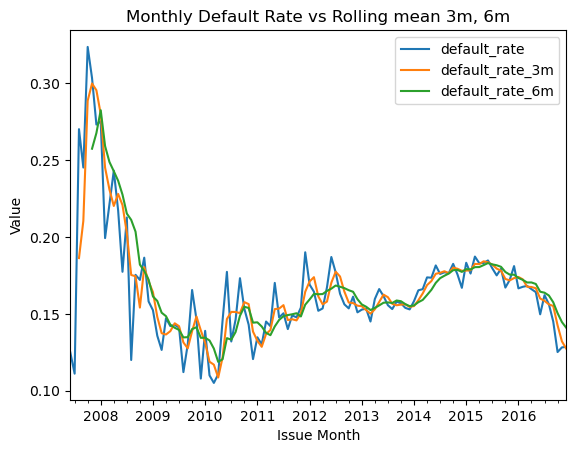

In [97]:
#plot the graphs again
monthly_default_rate_cleaned[['default_rate','default_rate_3m','default_rate_6m']].plot()
plt.xlabel("Issue Month")
plt.ylabel("Value")
plt.title("Monthly Default Rate vs Rolling mean 3m, 6m")
plt.savefig( r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\02_rolling_mean.png", dpi=300, bbox_inches="tight")
plt.show()

In [98]:
monthly_default_rate_cleaned['default_rate_std_6m']=monthly_default_rate_cleaned['default_rate'].rolling(6).std()
monthly_default_rate_cleaned.head(15)

C:\Users\owner's\AppData\Local\Temp\ipykernel_21152\4039402578.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_default_rate_cleaned['default_rate_std_6m']=monthly_default_rate_cleaned['default_rate'].rolling(6).std()


,total_loans,total_defaults,default_rate,default_rate_3m,default_rate_6m,default_rate_std_6m
issue_month,,,,,,
2007-06-01,24,3,0.125000,NaN,NaN,NaN
2007-07-01,63,7,0.111111,NaN,NaN,NaN
2007-08-01,74,20,0.270270,0.186335,NaN,NaN
2007-09-01,53,13,0.245283,0.210526,NaN,NaN
2007-10-01,105,34,0.323810,0.288793,NaN,NaN
2007-11-01,112,34,0.303571,0.300000,0.257541,0.090805
2007-12-01,172,47,0.273256,0.295630,0.267703,0.075442
2008-01-01,305,84,0.275410,0.280136,0.282582,0.027637
2008-02-01,306,61,0.199346,0.245211,0.259259,0.043966


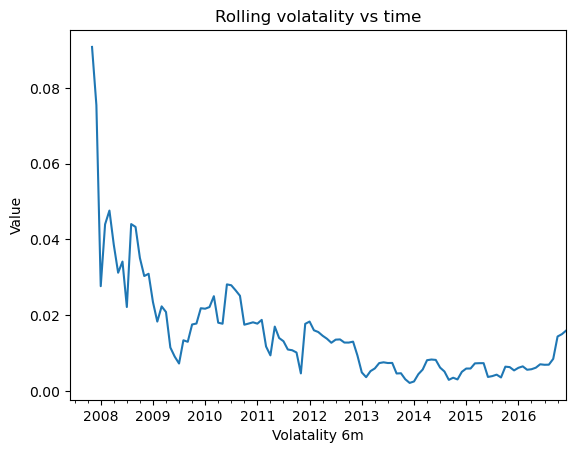

In [99]:
monthly_default_rate_cleaned['default_rate_std_6m'].plot()
plt.xlabel("Volatality 6m")
plt.ylabel("Value")
plt.title("Rolling volatality vs time")
plt.savefig( r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\03_rolling_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

**Volatility compression post-2010 indicates underwriting stabilization and portfolio scale maturity.**

## ADF TEST

In [100]:
from statsmodels.tsa.stattools import adfuller

In [101]:
def get_adfuller_stats(target):
    result=adfuller(target,autolag='AIC')
    data=[result[0],result[1]]
    idx=['adf_stat','p-value']
    df=pd.Series(data,index=idx)
    return df

In [102]:
print(get_adfuller_stats(monthly_default_rate_cleaned['default_rate']))

adf_stat   -3.111480
p-value     0.025715
dtype: float64


## ACF AND PACF PLOTS

In [103]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

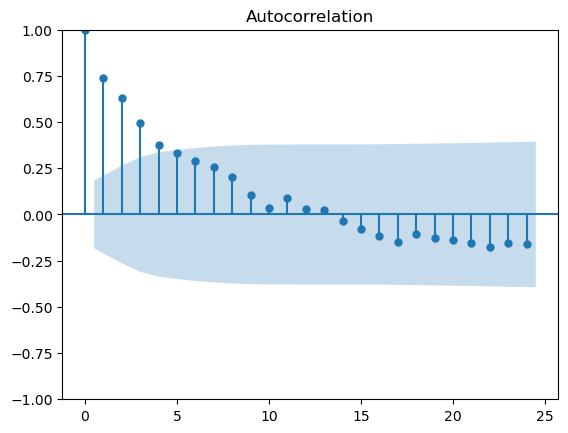

In [104]:
fig=plot_acf(monthly_default_rate_cleaned['default_rate'],lags=24)
fig.savefig( r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\04_acf.png", dpi=300, bbox_inches="tight")

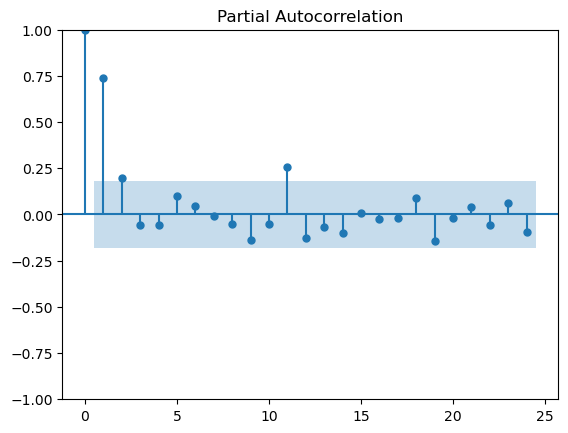

In [105]:
fig=plot_pacf(monthly_default_rate_cleaned['default_rate'],lags=24)
fig.savefig( r"E:\DV Data Science\credit-default-forecasting-system\reports\figures\05_pacf.png", dpi=300, bbox_inches="tight")

In [106]:
import json
from datetime import datetime

metadata = {
    "date_generated": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "date_range": {
        "start": str(monthly_default_rate_cleaned.index.min().date()),
        "end": str(monthly_default_rate_cleaned.index.max().date())
    },
    "total_months": int(len(monthly_default_rate_cleaned)),
    "total_loans": int(monthly_default_rate_cleaned["total_loans"].sum()),
    "total_defaults": int(monthly_default_rate_cleaned["total_defaults"].sum()),
    "average_default_rate": float(monthly_default_rate_cleaned["default_rate"].mean()),
    "cleaning_rule": "Removed last 24 months due to right-censoring bias."
}

with open("E:\DV Data Science\credit-default-forecasting-system\data\processed\monthly_default_rate_cleaned_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [107]:
# Export and freeze monthly_default_rate_cleaned
monthly_default_rate_cleaned.drop(['default_rate_3m','default_rate_6m','default_rate_std_6m'],axis=1,inplace=True)
monthly_default_rate_cleaned.reset_index(inplace=True)

C:\Users\owner's\AppData\Local\Temp\ipykernel_21152\1717052416.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_default_rate_cleaned.drop(['default_rate_3m','default_rate_6m','default_rate_std_6m'],axis=1,inplace=True)


In [109]:
monthly_default_rate_cleaned.to_csv(r"E:\DV Data Science\credit-default-forecasting-system\data\processed\monthly_default_rate_cleaned.csv",index=False)

#  Exploratory Time Series Analysis (EDA)
## Credit Portfolio Monthly Default Rate

---

## 1 Data Preparation & Bias Adjustment

### Right-Censoring Bias Identified

The initial time series showed an artificial decline in default rates after 2016.

**Reason:**
- Recently issued loans had not matured long enough to default.
- Loans still active were treated as non-default (0).
- This created downward bias in recent cohorts.

**Action Taken:**
- Removed last 24 months (post-2016) to eliminate incomplete performance window bias.

**Final Analysis Window:**
June 2007 – December 2016 (~110 months)

This ensures unbiased cohort-level default rate estimation.

---

## 2 Trend Analysis

### Observations

- **2007–2008:** Extremely high and volatile default rates (peaks above 30%).
- **2009–2011:** Sharp correction and stabilization.
- **2012–2016:** Gradual upward drift toward ~18%.

### Interpretation

- Early volatility due to:
  - Small portfolio size
  - Global Financial Crisis impact
- Post-2010 stabilization indicates underwriting maturity.
- 2012–2016 upward drift may reflect:
  - Portfolio expansion into riskier segments
  - Competitive lending pressure
  - Economic cycle normalization

The series exhibits **regime shifts**, not a simple linear trend.

---

## 3 Rolling Mean (3m, 6m)

- Short-term noise smoothed effectively.
- Clear visualization of regime transitions.
- Confirms volatility decline after early crisis period.

Rolling averages indicate structured movement rather than random noise.

---

## 4 Rolling Volatility (6-Month Standard Deviation)

### Observations

- Very high volatility in 2007–2008.
- Significant volatility compression after 2010.
- Stable volatility regime between 2013–2016.
- Mild uptick near 2016.

### Interpretation

- Volatility compression indicates portfolio stabilization.
- Risk profile became more predictable post-scale maturity.
- Early instability driven by small sample size and macro shock.

This suggests a transition to a stable credit risk regime.

---

## 5 Stationarity Test (ADF)

- **ADF Statistic:** -3.11  
- **p-value:** 0.0257  

At 5% significance level:

- Reject null hypothesis of unit root.
- Series is statistically stationary.
- Differencing likely not required (d = 0).

### Important Nuance

Although statistically stationary:

- Structural regime shifts are present.
- Stationarity does not imply absence of macro transitions.

---

## 6 Autocorrelation Function (ACF)

### Observations

- Strong autocorrelation at lag 1.
- Gradual decay across multiple lags.
- No sharp cutoff pattern.
- No strong seasonal spike at lag 12.

### Interpretation

- Behavior consistent with AR-type process.
- Weak evidence of strong yearly seasonality.

---

## 7 Partial Autocorrelation Function (PACF)

### Observations

- Significant spike at lag 1.
- Smaller spike at lag 2.
- Remaining lags mostly within confidence band.

### Interpretation

- Suggests AR(1) or AR(2) structure.
- Limited evidence for high-order AR components.

---

#  Overall Time Series Characteristics

- Weakly stationary
- Regime shifts present
- AR-dominant structure
- Limited seasonality
- Stabilized volatility post-2010
- Suitable for ARIMA(p,0,q) modeling

---

#  Modeling Implications

Based on EDA findings:

- Differencing likely unnecessary (d = 0).
- Candidate baseline models:
  - ARIMA(1,0,0)
  - ARIMA(2,0,0)
  - ARIMA(1,0,1)
  - ARIMA(2,0,1)
- SARIMA not immediately required due to weak seasonal signal.

---